In [39]:
# 📈 Cryptocurrency Market Intelligence Pipeline

## Project Objective

# This project aims to collect real-time cryptocurrency market data using the CoinGecko API, clean and transform the data with Pandas,
# perform exploratory data analysis (EDA), visualize key market metrics, and generate business insights from current market conditions.

#  Cryptocurrency Market Intelligence Pipeline

# │
# ├── Project Objective
# │
# ├── Import Libraries
# │
# ├── API Data Collection
# │
# ├── Convert JSON → DataFrame
# │
# ├── Data Cleaning & Transformation
# │
# ├── Save Clean Dataset
# │
# ├── Exploratory Data Analysis (EDA)
# │      │
# │      ├── info()
# │      ├── head()
# │      ├── describe()
# │      └── Dataset Insights
# │
# ├── Business Question 1
# │      │
# │      ├── Prepare Dataset
# │      ├── Chart
# │      └── Business Insights
# │
# ├── Business Question 2
# │      │
# │      ├── Prepare Dataset
# │      ├── Chart
# │      └── Business Insights
# │
# └── Final Findings


#this is step by step things i have done
# Business Objective
#         ↓
# API Request
#         ↓
# JSON
#         ↓
# raw_df
#         ↓
# clean_df
#         ↓
# Data Cleaning
#         ↓
# Transformation
#         ↓
# CSV
#         ↓
# EDA
#         ↓
# Business Questions
#         ↓
# Charts
#         ↓
# Business Insights
#         ↓
# Final Findings

In [40]:
import requests
url = "https://api.coingecko.com/api/v3/coins/markets"
params = {
    "vs_currency" : "usd" 
}
response = requests.get(url , params = params)
print(response.status_code)

200


In [41]:
data = response.json()
print(type(data))
print(data[0])


<class 'list'>
{'id': 'bitcoin', 'symbol': 'btc', 'name': 'Bitcoin', 'image': 'https://coin-images.coingecko.com/coins/images/1/large/bitcoin.png?1696501400', 'current_price': 60081, 'market_cap': 1204563290831, 'market_cap_rank': 1, 'fully_diluted_valuation': 1204564071873, 'total_volume': 14859223884, 'high_24h': 60784, 'low_24h': 59741, 'price_change_24h': -312.9896551894344, 'price_change_percentage_24h': -0.51824, 'market_cap_change_24h': -6401153907.575439, 'market_cap_change_percentage_24h': -0.5286, 'circulating_supply': 20049262.0, 'total_supply': 20049275.0, 'max_supply': 21000000.0, 'ath': 126080, 'ath_change_percentage': -52.34674, 'ath_date': '2025-10-06T18:57:42.558Z', 'atl': 67.81, 'atl_change_percentage': 88503.5515, 'atl_date': '2013-07-06T00:00:00.000Z', 'roi': None, 'last_updated': '2026-06-28T08:13:15.877Z'}


In [42]:
import pandas as pd
df_raw = pd.DataFrame(data)
# df.head()
df_raw.columns
# df.shape

Index(['id', 'symbol', 'name', 'image', 'current_price', 'market_cap',
       'market_cap_rank', 'fully_diluted_valuation', 'total_volume',
       'high_24h', 'low_24h', 'price_change_24h',
       'price_change_percentage_24h', 'market_cap_change_24h',
       'market_cap_change_percentage_24h', 'circulating_supply',
       'total_supply', 'max_supply', 'ath', 'ath_change_percentage',
       'ath_date', 'atl', 'atl_change_percentage', 'atl_date', 'roi',
       'last_updated'],
      dtype='object')

In [43]:
columns = [ "id",
    "symbol",
    "name",
    "current_price",
    "market_cap",
    "market_cap_rank",
    "total_volume",
    "price_change_percentage_24h",
    "last_updated"]

clean_df = df_raw[columns].copy()
clean_df



,id,symbol,name,current_price,market_cap,market_cap_rank,total_volume,price_change_percentage_24h,last_updated
0,bitcoin,btc,Bitcoin,60081.000000,1204563290831,1,1.485922e+10,-0.51824,2026-06-28T08:13:15.877Z
1,ethereum,eth,Ethereum,1572.010000,189718727627,2,5.123934e+09,-0.59973,2026-06-28T08:13:16.648Z
2,tether,usdt,Tether,0.998607,186078101237,3,2.581223e+10,0.00808,2026-06-28T08:13:16.751Z
3,binancecoin,bnb,BNB,554.860000,74787308805,4,4.922434e+08,-1.68051,2026-06-28T08:13:16.831Z
4,usd-coin,usdc,USDC,0.999730,73736199169,5,5.599935e+09,-0.00171,2026-06-28T08:13:16.931Z
...,...,...,...,...,...,...,...,...,...
95,flare-networks,flr,Flare,0.006666,577593186,96,2.514091e+06,-2.07405,2026-06-28T08:13:06.644Z
96,ylds,ylds,YLDS,1.000000,561632926,97,1.565791e+06,0.02312,2026-06-28T08:13:12.693Z
97,xdce-crowd-sale,xdc,XDC Network,0.027815,554808337,98,5.350157e+06,-1.35619,2026-06-28T08:13:06.762Z
98,usual-usd,usd0,Usual USD,0.998617,552813152,99,2.294860e+05,0.00422,2026-06-28T08:13:09.083Z


In [62]:
# 📊 Exploratory Data Analysis (EDA)
clean_df.info()
clean_df.head()
clean_df.describe()

## Dataset Insights
# - There are no missing values in the selected features, indicating good data completeness.
# - Cryptocurrency prices are highly right-skewed. The mean price is much higher than the median because a few assets, such as Bitcoin, have exceptionally high prices.
# - Daily price changes range from approximately -6.6% to +19.4%, indicating significant variation in short-term market performance.
# - Market capitalization and trading volume are concentrated among a small number of major cryptocurrencies.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype              
---  ------                       --------------  -----              
 0   id                           100 non-null    object             
 1   symbol                       100 non-null    object             
 2   name                         100 non-null    object             
 3   current_price                100 non-null    float64            
 4   market_cap                   100 non-null    int64              
 5   market_cap_rank              100 non-null    int64              
 6   total_volume                 100 non-null    float64            
 7   price_change_percentage_24h  99 non-null     float64            
 8   last_updated                 100 non-null    datetime64[ns, UTC]
dtypes: datetime64[ns, UTC](1), float64(3), int64(2), object(3)
memory usage: 7.2+ KB


,current_price,market_cap,market_cap_rank,total_volume,price_change_percentage_24h
count,100.000000,1.000000e+02,100.000000,1.000000e+02,99.000000
mean,721.691630,2.104564e+10,50.500000,6.056342e+08,0.168248
std,6025.090379,1.229592e+11,29.011492,3.037403e+09,9.388064
min,0.000002,5.234371e+08,1.000000,0.000000e+00,-28.236060
25%,0.318342,8.061929e+08,25.750000,5.744142e+06,-1.654950
50%,0.999925,1.468845e+09,50.500000,3.202162e+07,-0.518240
75%,6.590000,4.269503e+09,75.250000,8.717336e+07,0.017080
max,60081.000000,1.204563e+12,100.000000,2.581223e+10,78.080180


In [47]:
clean_df.nlargest(5,"market_cap")

,id,symbol,name,current_price,market_cap,market_cap_rank,total_volume,price_change_percentage_24h,last_updated
0,bitcoin,btc,Bitcoin,60081.000000,1204563290831,1,1.485922e+10,-0.51824,2026-06-28T08:13:15.877Z
1,ethereum,eth,Ethereum,1572.010000,189718727627,2,5.123934e+09,-0.59973,2026-06-28T08:13:16.648Z
2,tether,usdt,Tether,0.998607,186078101237,3,2.581223e+10,0.00808,2026-06-28T08:13:16.751Z
3,binancecoin,bnb,BNB,554.860000,74787308805,4,4.922434e+08,-1.68051,2026-06-28T08:13:16.831Z
4,usd-coin,usdc,USDC,0.999730,73736199169,5,5.599935e+09,-0.00171,2026-06-28T08:13:16.931Z


In [48]:
clean_df.nlargest(5,"price_change_percentage_24h")

,id,symbol,name,current_price,market_cap,market_cap_rank,total_volume,price_change_percentage_24h,last_updated
87,velvet,velvet,Velvet,1.560000,657535802,88,89158200.0,78.08018,2026-06-28T08:13:13.201Z
73,audiera,beat,Audiera,2.850000,821454627,74,36985903.0,32.55441,2026-06-28T08:13:14.875Z
92,pump-fun,pump,Pump.fun,0.001494,608016289,92,71495380.0,13.79671,2026-06-28T08:13:13.347Z
62,dexe,dexe,DeXe,22.400000,1047333571,63,12891008.0,7.68294,2026-06-28T08:13:04.214Z
37,near,near,NEAR Protocol,1.870000,2425129878,38,273858346.0,3.35360,2026-06-28T08:13:03.449Z


In [49]:
clean_df.nsmallest(5,"market_cap")

,id,symbol,name,current_price,market_cap,market_cap_rank,total_volume,price_change_percentage_24h,last_updated
99,bianrensheng,币安人生,币安人生 (BinanceLife),0.523438,523437081,100,37547742.0,-28.23606,2026-06-28T08:13:14.479Z
98,usual-usd,usd0,Usual USD,0.998617,552813152,99,229486.0,0.00422,2026-06-28T08:13:09.083Z
97,xdce-crowd-sale,xdc,XDC Network,0.027815,554808337,98,5350157.0,-1.35619,2026-06-28T08:13:06.762Z
96,ylds,ylds,YLDS,1.000000,561632926,97,1565791.0,0.02312,2026-06-28T08:13:12.693Z
95,flare-networks,flr,Flare,0.006666,577593186,96,2514091.0,-2.07405,2026-06-28T08:13:06.644Z


In [50]:
clean_df.nsmallest(5,"price_change_percentage_24h")

,id,symbol,name,current_price,market_cap,market_cap_rank,total_volume,price_change_percentage_24h,last_updated
99,bianrensheng,币安人生,币安人生 (BinanceLife),0.523438,523437081,100,37547742.0,-28.23606,2026-06-28T08:13:14.479Z
19,lab,lab,LAB,17.670000,5507025266,20,42297481.0,-11.52996,2026-06-28T08:13:14.692Z
14,zcash,zec,Zcash,383.300000,6435888459,15,256044358.0,-6.24264,2026-06-28T08:13:10.877Z
52,aave,aave,Aave,91.000000,1381364441,53,287716221.0,-4.86865,2026-06-28T08:13:04.167Z
83,jupiter-exchange-solana,jup,Jupiter,0.214814,713297915,84,31128439.0,-4.53929,2026-06-28T08:13:08.756Z


In [51]:
clean_df.to_csv(r"C:\Users\Pallav\Documents\pulkit\python beginner\crypto_market.csv", index = False)
loaded_df = pd.read_csv(r"C:\Users\Pallav\Documents\pulkit\python beginner\crypto_market.csv")
loaded_df.head()
loaded_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           100 non-null    object 
 1   symbol                       100 non-null    object 
 2   name                         100 non-null    object 
 3   current_price                100 non-null    float64
 4   market_cap                   100 non-null    int64  
 5   market_cap_rank              100 non-null    int64  
 6   total_volume                 100 non-null    float64
 7   price_change_percentage_24h  99 non-null     float64
 8   last_updated                 100 non-null    object 
dtypes: float64(3), int64(2), object(4)
memory usage: 7.2+ KB


In [52]:
clean_df["last_updated"] = pd.to_datetime(
    clean_df["last_updated"]
    )
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype              
---  ------                       --------------  -----              
 0   id                           100 non-null    object             
 1   symbol                       100 non-null    object             
 2   name                         100 non-null    object             
 3   current_price                100 non-null    float64            
 4   market_cap                   100 non-null    int64              
 5   market_cap_rank              100 non-null    int64              
 6   total_volume                 100 non-null    float64            
 7   price_change_percentage_24h  99 non-null     float64            
 8   last_updated                 100 non-null    datetime64[ns, UTC]
dtypes: datetime64[ns, UTC](1), float64(3), int64(2), object(3)
memory usage: 7.2+ KB


In [53]:
top_market_cap = (
    clean_df.nlargest(10,"market_cap")[["name","market_cap"]]
)
print(top_market_cap)

           name     market_cap
0       Bitcoin  1204563290831
1      Ethereum   189718727627
2        Tether   186078101237
3           BNB    74787308805
4          USDC    73736199169
5           XRP    65353601771
6        Solana    41250396952
7          TRON    30468138124
8  Figure Heloc    20163932936
9   Hyperliquid    13877286811


In [54]:
top_gainers = (
    clean_df.nlargest(10,"price_change_percentage_24h")[["name","price_change_percentage_24h"]]
)
print(top_gainers)

             name  price_change_percentage_24h
87         Velvet                     78.08018
73        Audiera                     32.55441
92       Pump.fun                     13.79671
62           DeXe                      7.68294
37  NEAR Protocol                      3.35360
90            ADI                      3.01599
58            Sky                      2.36824
76       Algorand                      2.24037
80           JUST                      1.76979
8    Figure Heloc                      1.52095


In [55]:
top_volume = (
    clean_df.nlargest(10,"total_volume")[["name","total_volume"]]
)
print(top_volume)

        name  total_volume
2     Tether  2.581223e+10
0    Bitcoin  1.485922e+10
4       USDC  5.599935e+09
1   Ethereum  5.123934e+09
6     Solana  1.609425e+09
5        XRP  1.090852e+09
22      USD1  5.316959e+08
3        BNB  4.922434e+08
10  Dogecoin  4.359777e+08
7       TRON  3.775101e+08


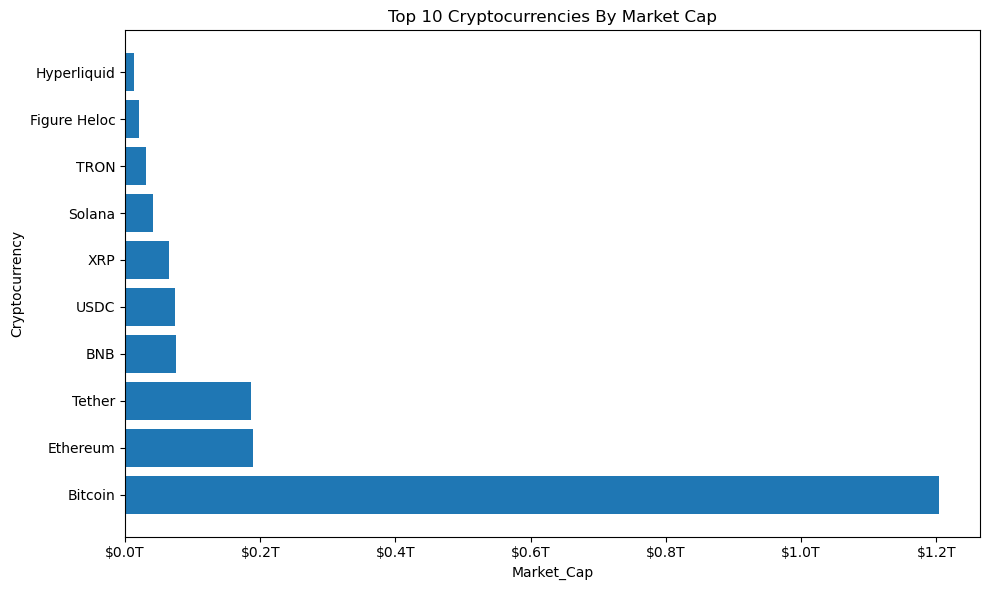

In [56]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
plt.figure(figsize=(10,6))

plt.barh(
    top_market_cap["name"] ,
    top_market_cap["market_cap"]
)
plt.title("Top 10 Cryptocurrencies By Market Cap")
plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x , pos : f"${x/1e12:.1f}T")
)
plt.xlabel("Market_Cap")
plt.ylabel("Cryptocurrency")
plt.tight_layout()
plt.show()

In [58]:
# Business Question 1
## Which cryptocurrencies dominate the market by market capitalization?

## Business Insights
# Insight 1 
# Bitcoin dominates the cryptocurrency market by a significant margin.
# Insight 2 
# Ethereum is the second-largest cryptocurrency but remains far behind Bitcoin in market capitalization. 
# Insight 3 
# Stablecoins such as Tether and USDC appear among the top assets, highlighting their importance in the crypto ecosystem. 
# Insight 4 
# Trading volume and market capitalization are heavily concentrated among a small number of leading cryptocurrencies, 
# indicating that market activity is dominated by major assets such as Bitcoin and Ethereum.

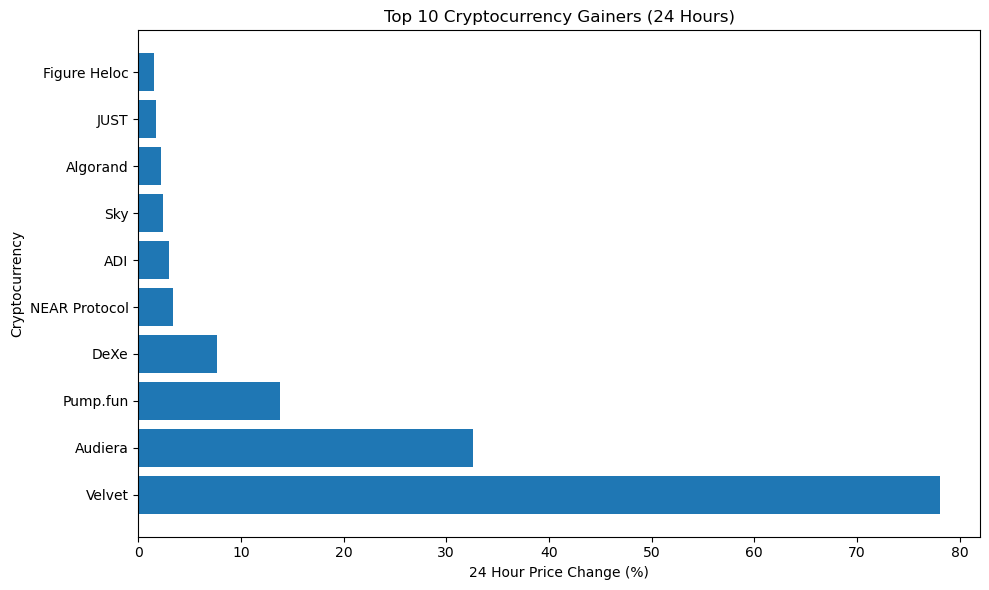

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    top_gainers["name"],
    top_gainers["price_change_percentage_24h"]
)

plt.title("Top 10 Cryptocurrency Gainers (24 Hours)")
plt.xlabel("24 Hour Price Change (%)")
plt.ylabel("Cryptocurrency")

plt.tight_layout()

plt.show()

In [ ]:
## Business Insights
# Insight 1 
# The strongest-performing cryptocurrency gained approximately XX% during the last 24 hours.
# Insight 2 
# The top gainers are primarily alternative cryptocurrencies rather than the largest market-cap assets.
# Insight 3
# Performance differences among the leading gainers are relatively small, indicating competitive short-term market momentum.
# Insight 4
# Significant positive daily returns suggest strong investor interest in selected cryptocurrencies during the observed period.

In [ ]:
# Final Findings

# - The cryptocurrency market is dominated by a small number of large-cap assets, with Bitcoin maintaining a significant lead.

# - Stablecoins remain among the largest cryptocurrencies, reflecting their importance in market liquidity.

# - Daily price performance varies considerably across cryptocurrencies, demonstrating the market's volatility.

# - The CoinGecko API provides structured and complete market data, making it well-suited for analytical workflows and future automation.

In [61]:
import os

os.makedirs("data", exist_ok=True)

df_raw.to_csv(
    "data/raw_crypto_market.csv",
    index=False
)

clean_df.to_csv(
    "data/clean_crypto_market.csv",
    index=False
)
print("Datasets saved successfully")

Datasets saved successfully
